# Watch training progress

This notebook only reads saved progress and logs. It does not load Whisper or start training.

Choose **Whisper (project .venv)** as the kernel. Change `RUN_TO_WATCH` to the run you want. Click **Run All** again to refresh while another terminal or notebook trains the model.

## 1. Choose a run

The stopped run is selected below so you can inspect what happened. Choose `whisper-small-kaa-full-run02` when you start the next run.

In [147]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").is_file():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Start inside the AI & ML project.")
    ROOT = ROOT.parent

RUN_TO_WATCH = "whisper-small-kaa-full-run02"
run_dir = ROOT / "checkpoints" / RUN_TO_WATCH
log_file = ROOT / "checkpoints" / f"{RUN_TO_WATCH}.log"
progress_file = run_dir / "progress.json"

## 2. See the current stage

`training` means weights are being updated. `validation` checks loss between epochs. `evaluation` generates transcripts after training. `stopped` means the process was stopped.

The progress bar measures training epochs or evaluation recordings, depending on the current stage.

Status: completed
Evaluation split: validation


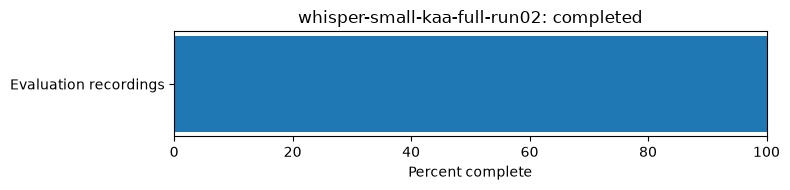

In [148]:
progress = {}
if progress_file.exists():
    progress = json.loads(progress_file.read_text())
    print("Status:", progress["status"])
    if "epoch" in progress:
        print("Epoch:", progress["epoch"], "/", progress["epochs"])
        print("Batch:", progress.get("batch", 0), "/", progress.get("batches", 0))
        print("Weight updates:", progress.get("updates", 0))
    if "split" in progress:
        print("Evaluation split:", progress["split"])
else:
    print("No progress file yet. The run may not have started its first weight update.")

if progress:
    if progress["status"] in ["evaluation", "completed"]:
        fraction = progress.get("recording", 0) / max(1, progress.get("recordings", 1))
        label = "Evaluation recordings"
    elif progress["status"] == "finished":
        fraction = 1.0
        label = "Training epochs"
    else:
        batch_fraction = progress.get("batch", 0) / max(1, progress.get("batches", 1))
        fraction = (progress.get("epoch", 1) - 1 + batch_fraction) / progress.get("epochs", 1)
        label = "Training epochs"
    plt.figure(figsize=(8, 2))
    plt.barh([label], [fraction * 100])
    plt.xlim(0, 100)
    plt.xlabel("Percent complete")
    plt.title(f"{RUN_TO_WATCH}: {progress['status']}")
    plt.tight_layout()
    plt.show()

## 3. Plot the training loss

Each point is the average training token loss so far in that epoch, recorded after a weight update. New runs save loss_history.csv in either Jupyter or terminal mode. The stopped older run uses its terminal log as a fallback. Lower training loss is not a recognition accuracy score.

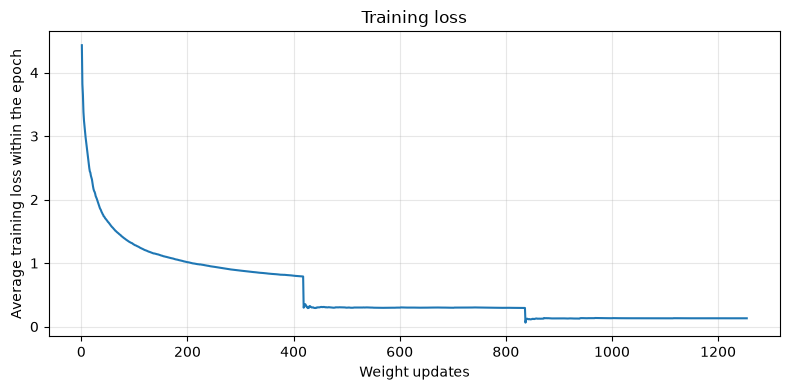

In [149]:
updates = []
losses = []
loss_file = run_dir / "loss_history.csv"
if loss_file.exists():
    losses_table = pd.read_csv(loss_file).dropna()
    updates = losses_table["updates"].tolist()
    losses = losses_table["train_loss"].tolist()
elif log_file.exists():
    for line in log_file.read_text().splitlines():
        if line.startswith("Epoch ") and "updates " in line and "loss " in line:
            parts = line.split("|")
            updates.append(int(parts[2].split()[-1]))
            losses.append(float(parts[3].split()[-1]))

if updates:
    plt.figure(figsize=(8, 4))
    plt.plot(updates, losses)
    plt.xlabel("Weight updates")
    plt.ylabel("Average training loss within the epoch")
    plt.title("Training loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No logged weight updates yet. The next run saves a loss_history.csv file for this curve.")

## 4. Compare completed epochs

Validation loss is written at the end of each epoch. The stopped first run has no completed epoch, so this table is not available yet.

,epoch,train_loss,validation_loss,updates
0,1,0.789437,0.562612,418
1,2,0.293848,0.466510,836
2,3,0.131154,0.458571,1254


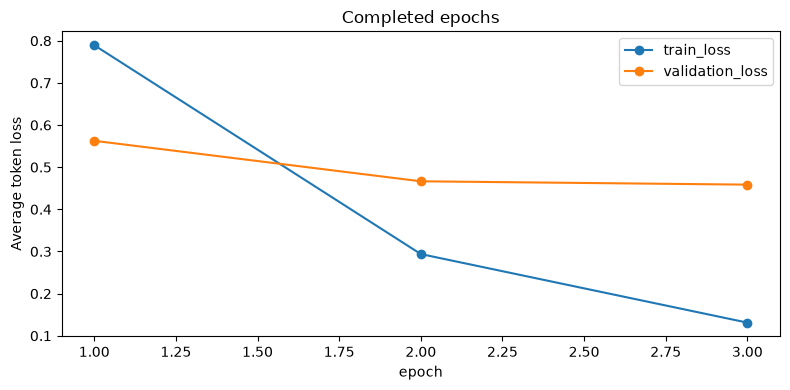

In [150]:
history_file = run_dir / "history.json"
if history_file.exists():
    history = pd.DataFrame(json.loads(history_file.read_text()))
    display(history)
    history.plot(x="epoch", y=["train_loss", "validation_loss"], marker="o", figsize=(8, 4))
    plt.ylabel("Average token loss")
    plt.title("Completed epochs")
    plt.tight_layout()
    plt.show()
else:
    print("No completed epoch or validation loss yet.")